In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import make_classification

In [34]:
X,y=make_classification(n_samples=50,n_features=5,n_redundant=0,n_informative=5,n_clusters_per_class=1,random_state=42)

In [35]:
df=pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target']=y
print(df.shape)

(50, 6)


In [36]:
df.head()

,col1,col2,col3,col4,col5,target
0,-1.071976,2.069819,0.787854,1.395057,1.016155,0
1,-0.181406,-0.698090,1.214970,1.004752,0.444763,1
2,1.535059,0.194080,-1.159615,-1.238588,-2.452897,1
3,0.172627,0.908349,1.356917,0.747706,0.073888,0
4,0.615262,-0.780442,-1.621553,-1.719576,-1.746630,1


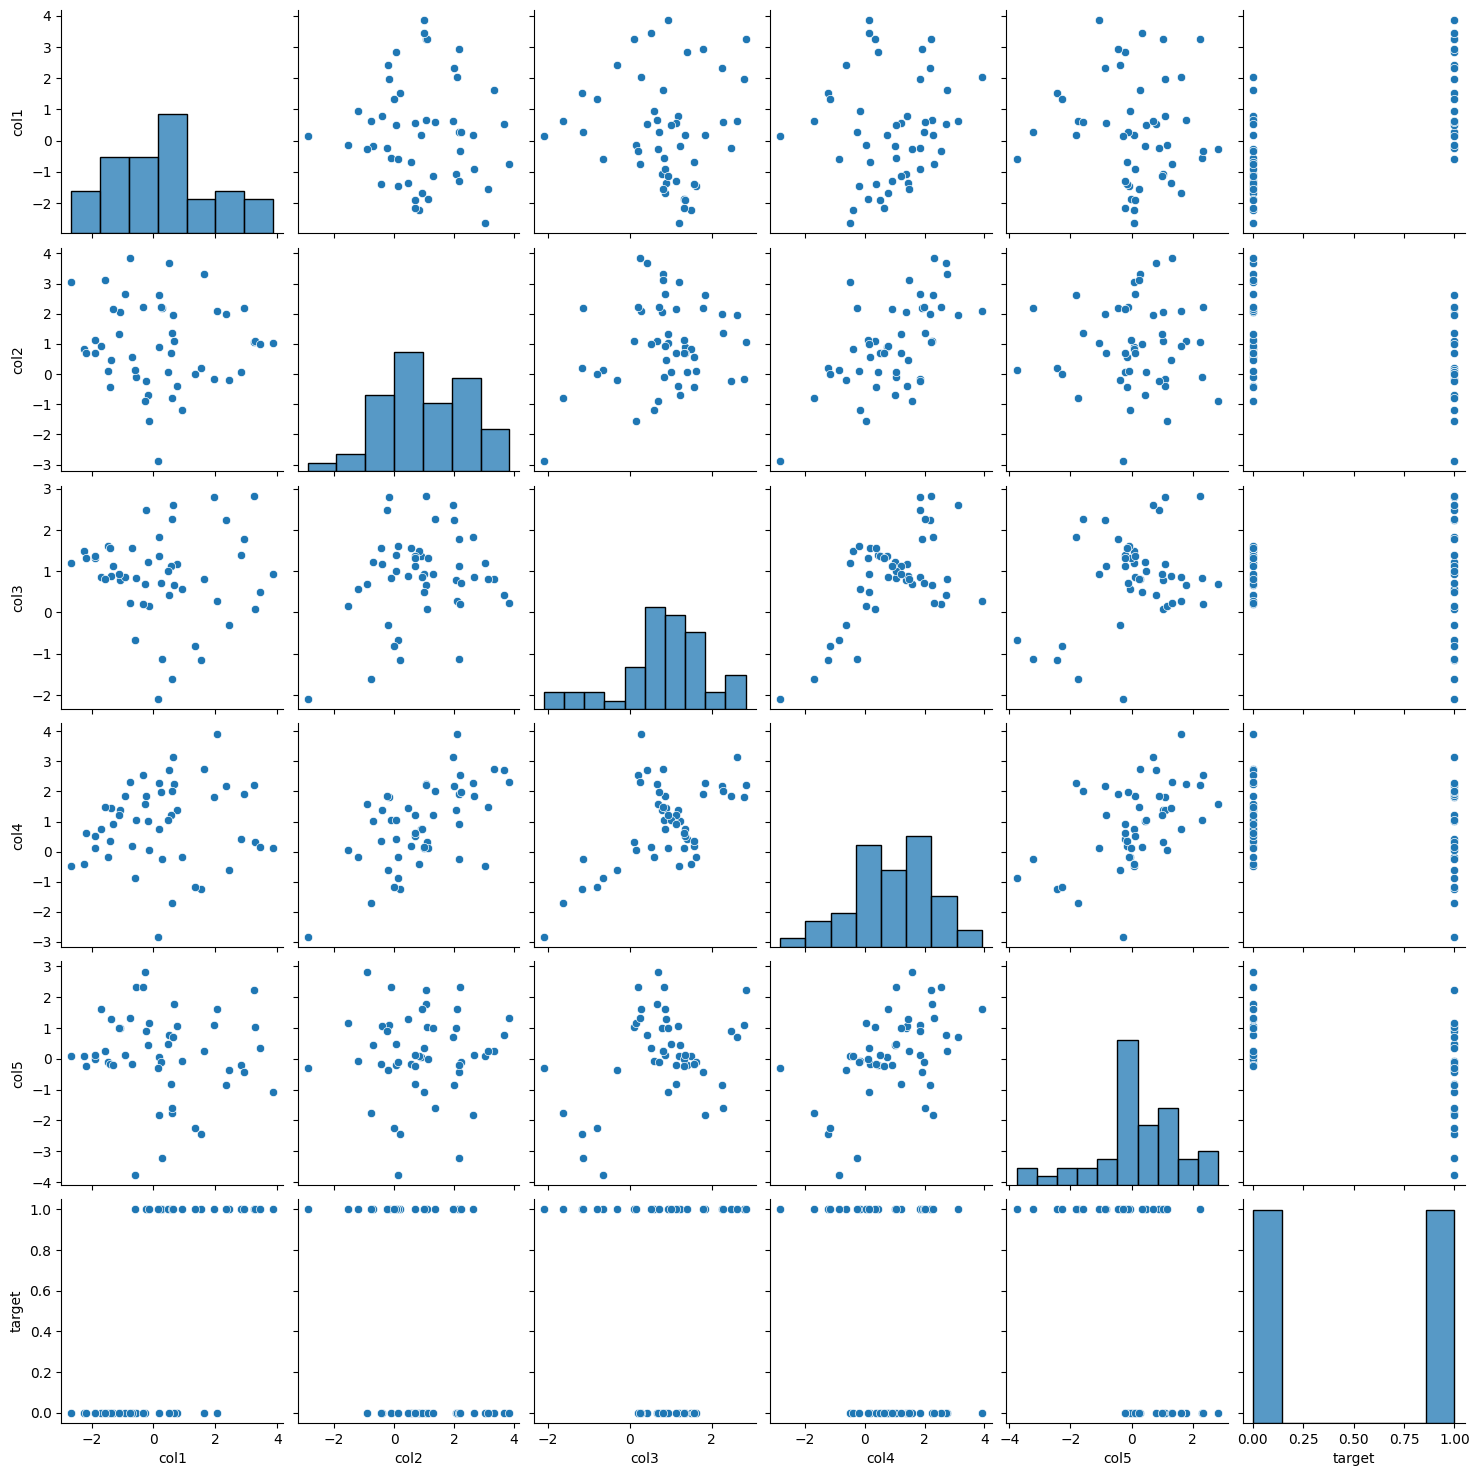

In [37]:
sns.pairplot(df)
plt.show()

In [38]:
from sklearn.model_selection import train_test_split

In [39]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [40]:
X_train.shape

(40, 5)

In [41]:
from sklearn.tree import DecisionTreeClassifier

In [42]:
DT=DecisionTreeClassifier()

In [43]:
DT.fit(X_train,y_train)

DecisionTreeClassifier()

In [44]:
y_pred=DT.predict(X_test)

In [45]:
from sklearn.metrics import accuracy_score

In [46]:
print(accuracy_score(y_test,y_pred))

1.0


In [47]:
from sklearn.tree import plot_tree

[Text(0.4090909090909091, 0.9285714285714286, 'x[0] <= -0.252\ngini = 0.489\nsamples = 40\nvalue = [17, 23]'),
 Text(0.18181818181818182, 0.7857142857142857, 'x[3] <= -0.672\ngini = 0.142\nsamples = 13\nvalue = [12, 1]'),
 Text(0.29545454545454547, 0.8571428571428572, 'True  '),
 Text(0.09090909090909091, 0.6428571428571429, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.2727272727272727, 0.6428571428571429, 'gini = 0.0\nsamples = 12\nvalue = [12, 0]'),
 Text(0.6363636363636364, 0.7857142857142857, 'x[3] <= 2.238\ngini = 0.302\nsamples = 27\nvalue = [5, 22]'),
 Text(0.5227272727272727, 0.8571428571428572, '  False'),
 Text(0.45454545454545453, 0.6428571428571429, 'x[0] <= 0.853\ngini = 0.165\nsamples = 22\nvalue = [2, 20]'),
 Text(0.36363636363636365, 0.5, 'x[0] <= 0.694\ngini = 0.32\nsamples = 10\nvalue = [2, 8]'),
 Text(0.2727272727272727, 0.35714285714285715, 'x[2] <= 1.286\ngini = 0.198\nsamples = 9\nvalue = [1, 8]'),
 Text(0.18181818181818182, 0.21428571428571427, 'gini = 0.0

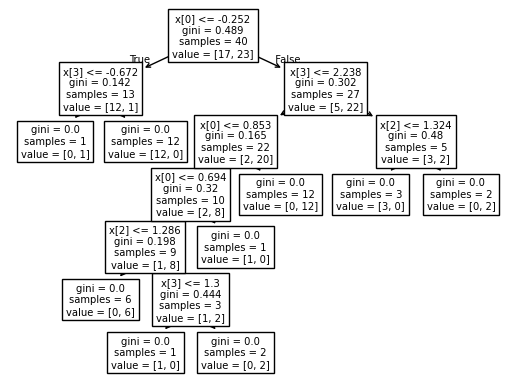

In [48]:
plot_tree(DT)

In [49]:
# function for row sampling

def sample_row(df,percent):
    return df.sample(int(percent*df.shape[0]),replace=True)

In [59]:
import random

In [63]:
# function for features sampling

def sample_feature(df,percentage):
    cols = random.sample(df.columns.tolist()[:-1],int(percentage*(df.shape[1]-1)))
    new_df=df[cols]
    new_df['target']=df['target']
    return new_df

In [64]:
# function that combines both the samplpling

def sample_combined(df,percent_row,percent_col):
    new_df=sample_row(df,percent_row)
    return sample_feature(new_df,percent_col)

In [65]:
df1 = sample_combined(df,0.5,0.5)

C:\Users\Priti\AppData\Local\Temp\ipykernel_1356\2354865689.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target']=df['target']


In [66]:
df2 = sample_combined(df,0.5,0.5)

C:\Users\Priti\AppData\Local\Temp\ipykernel_1356\2354865689.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target']=df['target']


In [67]:
df3 = sample_combined(df,0.5,0.5)

C:\Users\Priti\AppData\Local\Temp\ipykernel_1356\2354865689.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target']=df['target']


In [71]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col2', 'col1', 'target'], dtype='object')
Index(['col4', 'col5', 'target'], dtype='object')
Index(['col1', 'col5', 'target'], dtype='object')


In [79]:
df3

,col1,col5,target
19,-0.695614,-0.164317,0
39,-1.372572,1.280559,0
48,-1.548800,0.245641,0
2,1.535059,-2.452897,1
39,-1.372572,1.280559,0
0,-1.071976,1.016155,0
24,2.841082,-0.213255,1
12,-2.650514,0.091479,0
20,3.250775,2.235964,1
11,0.284727,-3.219084,1


In [72]:
from sklearn.tree import DecisionTreeClassifier

In [73]:
clf1=DecisionTreeClassifier()
clf2=DecisionTreeClassifier()
clf3=DecisionTreeClassifier()

In [74]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

DecisionTreeClassifier()

In [75]:
from sklearn.tree import plot_tree

[Text(0.375, 0.9, 'x[1] <= 0.216\ngini = 0.499\nsamples = 25\nvalue = [13, 12]'),
 Text(0.16666666666666666, 0.7, 'x[0] <= -1.888\ngini = 0.153\nsamples = 12\nvalue = [11, 1]'),
 Text(0.2708333333333333, 0.8, 'True  '),
 Text(0.08333333333333333, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.25, 0.5, 'gini = 0.0\nsamples = 11\nvalue = [11, 0]'),
 Text(0.5833333333333334, 0.7, 'x[0] <= -0.165\ngini = 0.26\nsamples = 13\nvalue = [2, 11]'),
 Text(0.4791666666666667, 0.8, '  False'),
 Text(0.4166666666666667, 0.5, 'x[0] <= -0.587\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.3333333333333333, 0.3, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.5, 0.3, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.75, 0.5, 'x[0] <= 2.045\ngini = 0.165\nsamples = 11\nvalue = [1, 10]'),
 Text(0.6666666666666666, 0.3, 'gini = 0.0\nsamples = 9\nvalue = [0, 9]'),
 Text(0.8333333333333334, 0.3, 'x[1] <= 1.153\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.75, 0.1, 'gini = 0.0\nsam

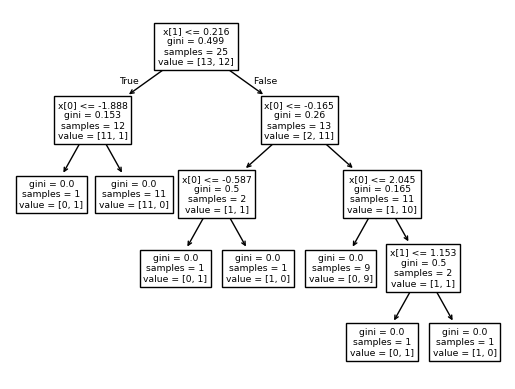

In [76]:
plot_tree(clf1)

[Text(0.4, 0.9166666666666666, 'x[1] <= -0.256\ngini = 0.499\nsamples = 25\nvalue = [13, 12]'),
 Text(0.3, 0.75, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.35, 0.8333333333333333, 'True  '),
 Text(0.5, 0.75, 'x[0] <= 1.613\ngini = 0.432\nsamples = 19\nvalue = [13, 6]'),
 Text(0.45, 0.8333333333333333, '  False'),
 Text(0.3, 0.5833333333333334, 'x[0] <= 0.203\ngini = 0.165\nsamples = 11\nvalue = [10, 1]'),
 Text(0.2, 0.4166666666666667, 'x[1] <= 0.629\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.1, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.3, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.4, 0.4166666666666667, 'gini = 0.0\nsamples = 9\nvalue = [9, 0]'),
 Text(0.7, 0.5833333333333334, 'x[0] <= 2.386\ngini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.6, 0.4166666666666667, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.8, 0.4166666666666667, 'x[1] <= 1.164\ngini = 0.48\nsamples = 5\nvalue = [3, 2]'),
 Text(0.7, 0.25, 'x[0] <= 2.942\ngini

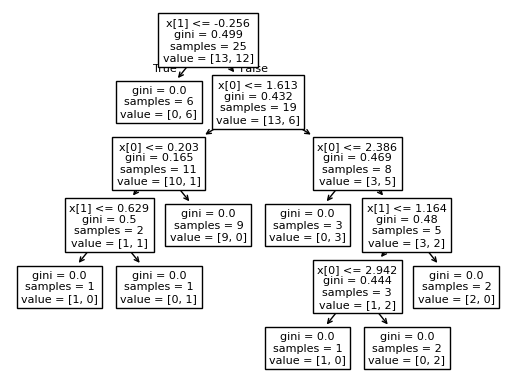

In [77]:
plot_tree(clf2)

[Text(0.3333333333333333, 0.9, 'x[0] <= -0.297\ngini = 0.499\nsamples = 25\nvalue = [12, 13]'),
 Text(0.16666666666666666, 0.7, 'gini = 0.0\nsamples = 10\nvalue = [10, 0]'),
 Text(0.25, 0.8, 'True  '),
 Text(0.5, 0.7, 'x[1] <= 0.617\ngini = 0.231\nsamples = 15\nvalue = [2, 13]'),
 Text(0.41666666666666663, 0.8, '  False'),
 Text(0.3333333333333333, 0.5, 'gini = 0.0\nsamples = 10\nvalue = [0, 10]'),
 Text(0.6666666666666666, 0.5, 'x[0] <= 1.958\ngini = 0.48\nsamples = 5\nvalue = [2, 3]'),
 Text(0.5, 0.3, 'x[0] <= 0.133\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.3333333333333333, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.6666666666666666, 0.1, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.8333333333333334, 0.3, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]')]

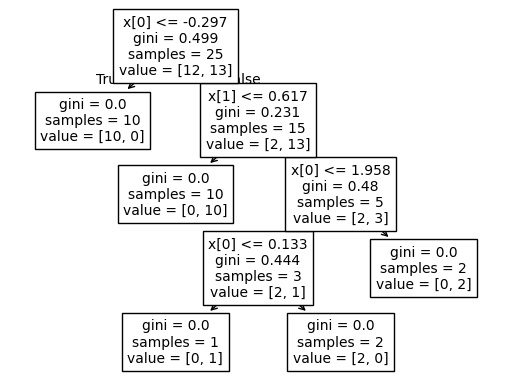

In [78]:
plot_tree(clf3)

In [84]:
clf1.predict(np.array([3.862098,	-1.062753]).reshape(1,2))

C:\Users\Priti\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [85]:
clf2.predict(np.array([3.862098,	-1.062753]).reshape(1,2))

C:\Users\Priti\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [86]:
clf3.predict(np.array([3.862098,	-1.062753]).reshape(1,2))

C:\Users\Priti\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [89]:
from sklearn.model_selection import cross_val_score

In [90]:
estimators = [('dt1',clf1),('dt2',clf2),('dt3',clf3)]

In [91]:
for estimator in estimators:
        x = cross_val_score(estimator[1],X,y,cv=10,scoring='accuracy')
        print(estimator[0],np.round(np.mean(x),2))

dt1 0.76
dt2 0.76
dt3 0.78
